In [2]:
import numpy as np
import matplotlib.pyplot as plt
import bibfunciones as bf
import scipy.constants as cte

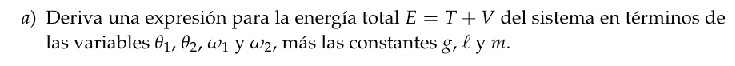

De las siguientes imagenes obtenemos expresiones para T y V. \
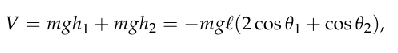 \
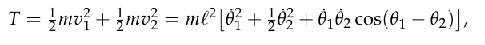 \
Por lo tanto, la energía queda de la siguiente manera:

In [3]:
#### Energía
def Energia(z1,z2,z1_p,z2_p, m, l):
    g = 9.81
    E = m*l**2*(z1_p**2+z2_p**2/2+z1_p*z2_p*np.cos(z1-z2))-m*g*l*(2*np.cos(z1)+np.cos(z2))
    return E

Ahora resolvemos las ecuaciones de movimiento. \
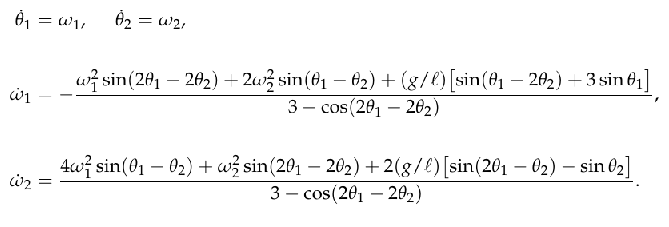

In [4]:
def PO_punto(z,l):
    g = 9.81
    d_theta_1 = z[2]
    d_theta_2 = z[3]
    d_omega_1 = -(z[2]**2*np.sin(2*z[0]-2*z[1])+2*z[3]**2*np.sin(z[0]-z[1])+(g/l)*np.sin(z[0]-2*z[1])+3*np.sin(z[0]))/(3-np.cos(2*z[0]-2*z[1]))
    d_omega_2 = (4*z[2]**2*np.sin(2*z[0]-2*z[1])+z[3]**2*np.sin(2*(z[0]-z[1]))+2*(g/l)*np.sin(2*z[0]-z[1])+np.sin(z[1]))/(3-np.cos(2*z[0]-2*z[1]))
    return np.array([d_theta_1,d_theta_2,d_omega_1, d_omega_2])

In [35]:
#Runge_kutta_4orden 
def Pendulo_doble(theta1,theta2,omega1,omega2,l,tf):
    p0 = np.array([theta1,theta2,omega1,omega2])
    X1 = [p0[0]]
    X2 = [p0[1]]
    Y1 = [p0[2]]
    Y2 = [p0[3]]
    t = 0
    T1 = [t]
    dt = 1e-4
    while (t<=tf):
        k1 = dt*PO_punto(p0,l)
        k2 = dt*PO_punto(p0+k1/2,l)
        k3 = dt*PO_punto(p0+k2/2,l)
        k4 = dt*PO_punto(p0+k3,l)
        p0 = p0 + (k1+2*k2+2*k3+k4)/6
        t = t + dt
        X1.append(p0[0])
        X2.append(p0[1])
        Y1.append(p0[2])
        Y2.append(p0[3])
        T1.append(t)
    return X1, X2 ,Y1, Y2, T1

In [42]:
EC_mov = Pendulo_doble(np.pi/2,np.pi/2,0,0,0.4,100)

In [43]:
EC_mov = np.array(EC_mov)
Energy = Energia(EC_mov[0], EC_mov[1], EC_mov[2], EC_mov[3], 1, 0.4)

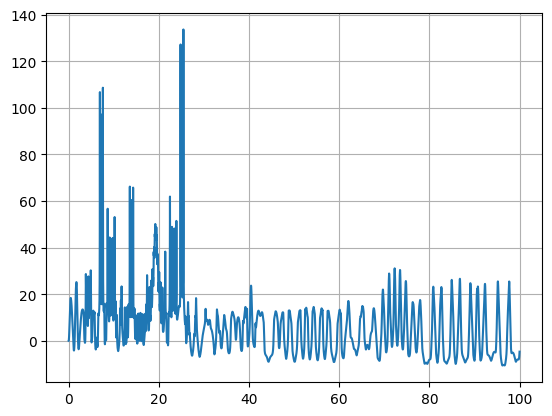

In [45]:
plt.plot(EC_mov[4], Energy)
plt.grid()